<a href="https://colab.research.google.com/github/ValentinaEmili/Texture-synthesis/blob/main/training/training_TT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
!pip install lpips

In [3]:
import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.optim as optim
from torchvision.models import vgg16
import matplotlib.pyplot as plt
import time
import lpips
import sys

In [4]:
REPO_DIR = '/content/Texture_synthesis'
os.chdir('/content')

if not os.path.exists(REPO_DIR):
  !git clone https://github.com/ValentinaEmili/Texture-synthesis.git Texture_synthesis

if REPO_DIR not in sys.path:
  sys.path.append(REPO_DIR)

Cloning into 'Texture_synthesis'...
remote: Enumerating objects: 495, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 495 (delta 35), reused 8 (delta 8), pack-reused 437 (from 1)
Receiving objects: 100% (495/495), 48.41 MiB | 12.41 MiB/s, done.
Resolving deltas: 100% (224/224), done.


In [5]:
!pip install import-ipynb -q
import import_ipynb
from Texture_synthesis.codebook.VQGAN.VQGAN_TT import VQGAN, Discriminator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.8 MB/s eta 0:00:00


In [6]:
train_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(256),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

eval_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])


class DTD_Dataset(Dataset):
    def __init__(self, root, file_list, transform=None, class_to_idx=None):
        self.root = root
        self.transform = transform

        with open(file_list, mode='r', encoding='utf-8') as f:
            self.files = [line.strip() for line in f if line.strip()]

        if class_to_idx is None:
          unique_classes = sorted({os.path.normpath(p).split(os.sep)[0] for p in self.files})
          self.class_to_idx = {class_name: i for i, class_name in enumerate(unique_classes)}
        else:
          self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        relative_path = self.files[idx]
        image_path = os.path.join(self.root, relative_path)
        img = Image.open(image_path).convert('RGB')
        rel_norm = os.path.normpath(relative_path)
        string_label = rel_norm.split(os.sep, 1)[0]
        label = self.class_to_idx[string_label]

        if self.transform:
            img = self.transform(img)

        return img, label

In [7]:
path_images = "drive/MyDrive/DeepLearning/dtd/images"
path_labels = "drive/MyDrive/DeepLearning/dtd/labels"

def merge_files(input_files, output_file):
  out_file_path = os.path.join(path_labels, output_file)

  with open(out_file_path, mode='w', encoding='utf-8') as out_f:
    for file in input_files:
      in_file_path = os.path.join(path_labels, file)

      with open(in_file_path, mode='r', encoding='utf-8') as in_f:
        for line in in_f:
          line = line.strip()
          if line:
            out_f.write(line + '\n')

#merge_files(['train1.txt', 'train2.txt'], 'train_1_2.txt')
#merge_files(['val1.txt', 'val2.txt'], 'val_1_2.txt')
#merge_files(['test1.txt', 'test2.txt'], 'test_1_2.txt')
train_dataset = DTD_Dataset(path_images, os.path.join(path_labels, "train2.txt"), train_transform)
class_to_idx = train_dataset.class_to_idx
val_dataset = DTD_Dataset(path_images, os.path.join(path_labels, "val2.txt"), eval_transform, class_to_idx=class_to_idx)
test_dataset = DTD_Dataset(path_images, os.path.join(path_labels, "test2.txt"), eval_transform, class_to_idx=class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = VQGAN().to(device)
discriminator = Discriminator().to(device)
optimizer_generator = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.9))
optimizer_discriminator = optim.Adam(discriminator.parameters(), lr=5e-5, betas=(0.5, 0.9))
perceptual_loss_fn = lpips.LPIPS(net='vgg').to(device)

perceptual_loss_fn.eval()
for p in perceptual_loss_fn.parameters():
    p.requires_grad_(False)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 113MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/vgg.pth


## Validation

In [11]:
def visual_validation(generator, val_loader, device, show_imgs=True):
  generator.eval()
  all_indices = []
  visual_samples = None
  total_loss, total_recon_loss, total_percept_loss, total_vq_loss = 0.0, 0.0, 0.0, 0.0

  num_embeddings = generator.vq.num_embeddings
  embedding_dim = generator.vq.embedding_dim
  embeddings = generator.vq.embeddings.weight

  with torch.no_grad():
    for batch_idx, (data, _) in enumerate(val_loader):
      data = data.to(device)
      recon_batch, vq_loss = generator(data)

      visual_samples = (data.cpu(), recon_batch.cpu())

      recon_loss = F.mse_loss(recon_batch, data)
      percept_loss = perceptual_loss_fn(recon_batch, data).mean()
      loss = percept_loss + vq_loss + recon_loss * 0.2

      total_loss += loss.item()
      total_recon_loss += recon_loss.item()
      total_percept_loss += percept_loss.item()
      total_vq_loss += vq_loss.item()

      z = generator.encoder(data)
      z = generator.quant_conv(z)
      z_flattened = z.permute(0, 2, 3, 1).contiguous().view(-1, embedding_dim)

      distances = (torch.sum(z_flattened**2, dim=1, keepdim=True)
                    + torch.sum(embeddings**2, dim=1)
                    - 2 * torch.matmul(z_flattened, embeddings.t()))

      all_indices.append(torch.argmin(distances, dim=1))

  # percentage of used vectors
  encoding_indices = torch.cat(all_indices)
  unique_indices = torch.unique(encoding_indices)
  util_percen = len(unique_indices) / num_embeddings * 100

  # perplexity
  counts = torch.bincount(encoding_indices, minlength=num_embeddings).float()
  probs = counts / counts.sum()
  perplexity = torch.exp(-torch.sum(probs * torch.log(probs + 1e-10)))

  avg_loss = total_loss / len(val_loader)
  avg_recon_loss = total_recon_loss / len(val_loader)
  avg_percept_loss = total_percept_loss / len(val_loader)
  avg_vq_loss = total_vq_loss / len(val_loader)

  selection_score = avg_percept_loss + 0.2 * avg_recon_loss
  unique_vectors_used = (len(unique_indices) / num_embeddings) * 100

  print(f"Val Loss: {avg_loss:.4f}  | Perceptual Loss: {avg_percept_loss:.4f}  | Reconstruction Loss: {avg_recon_loss:.4f}  | Codebook Loss: {avg_vq_loss:.4f}")
  print(f"Unique Vectors Used: {unique_vectors_used:.4f}%  | Codebook Utilization: {util_percen:.2f}%  | Codebook Perplexity: {perplexity.item():.2f}")

  # visual reconstruction plotting
  if (show_imgs):
    real_imgs, recon_imgs = visual_samples
    num_displayed_imgs = min(4, real_imgs.shape[0])

    fig, axes = plt.subplots(2, num_displayed_imgs, figsize=(num_displayed_imgs * 3, 6))

    for i in range(num_displayed_imgs):
      real_img = real_imgs[i].permute(1, 2, 0).numpy()
      recon_img = recon_imgs[i].permute(1, 2, 0).numpy()

      real_plot = ((real_img + 1) / 2).clip(0, 1)
      recon_plot = ((recon_img + 1) / 2).clip(0, 1)

      axes[0, i].imshow(real_plot)
      axes[0, i].set_title(f"original {i+1}")
      axes[0, i].axis('off')

      axes[1, i].imshow(recon_plot)
      axes[1, i].set_title(f"reconstructed {i+1}")
      axes[1, i].axis('off')

    plt.show()

  return selection_score, unique_vectors_used, perplexity.item()

## Training

In [12]:
def calculate_adaptive_weight(recon_loss, g_loss, last_layer_weights):
    recon_grads = torch.autograd.grad(recon_loss, last_layer_weights, retain_graph=True, allow_unused=True)[0]
    g_grads = torch.autograd.grad(g_loss, last_layer_weights, retain_graph=True, allow_unused=True)[0]

    if recon_grads is None:
      recon_norm = torch.tensor(0., device=last_layer_weights.device)
    else:
      recon_norm = torch.norm(recon_grads)

    if g_grads is None:
      g_norm = torch.tensor(0., device=last_layer_weights.device)
    else:
      g_norm = torch.norm(g_grads)

    lambda_weight = recon_norm / (g_norm + 1e-4)
    lambda_weight = torch.clamp(lambda_weight, 0.0, 1e4).detach()
    return lambda_weight

In [14]:
def set_requires_grad(model, requires_grad):
  for param in model.parameters():
    param.requires_grad = requires_grad

def train_step(generator, discriminator, perceptual_loss_fn, data, optimizer_g, optimizer_d, disc_start_step, current_global_step):
    # GENERATOR

    # disable discriminator gradients while training generator
    set_requires_grad(discriminator, False)

    optimizer_g.zero_grad()

    recon_batch, vq_loss = generator(data)

    recon_loss = F.mse_loss(recon_batch, data)
    percept_loss = perceptual_loss_fn(recon_batch, data).mean()

    # dynamic adaptive weight scheduling
    if current_global_step >= disc_start_step:
        fake_outputs = discriminator(recon_batch)
        g_loss = -fake_outputs.mean()   # hinge loss

        last_layer_weights = generator.decoder.conv_out.weight
        disc_weight = calculate_adaptive_weight(recon_loss + percept_loss, g_loss, last_layer_weights)

        gen_loss = vq_loss + recon_loss + percept_loss + (disc_weight * g_loss)
    else:
        gen_loss = vq_loss + recon_loss + percept_loss

    gen_loss.backward()
    optimizer_g.step()
    set_requires_grad(discriminator, True)

    # DISCRIMINATOR
    disc_loss = torch.tensor(0.0, device=data.device)
    if current_global_step >= disc_start_step:
        optimizer_d.zero_grad()

        real_outputs = discriminator(data)
        fake_outputs_d = discriminator(recon_batch.detach())

        loss_real = F.relu(1.0 - real_outputs).mean()
        loss_fake = F.relu(1.0 + fake_outputs_d).mean()

        disc_loss = 0.5 * loss_real + 0.5 * loss_fake
        disc_loss.backward()
        optimizer_d.step()

    return gen_loss.item(), disc_loss.item()

In [ ]:
def train_and_validation(generator, discriminator, train_loader, val_loader, device, save_path, global_step, disc_start_step, epochs=20, best_val_score=float('inf'), show_imgs=True):
  gen_best_save_path = os.path.join(save_path, f"gen_best_2.pth")
  disc_best_save_path = os.path.join(save_path, f"disc_best_2.pth")

  for epoch in range(epochs):
    generator.train()
    discriminator.train()

    total_loss_gen, total_loss_disc = 0.0, 0.0

    # training
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        gen_loss, disc_loss = train_step(
                                    generator, discriminator, perceptual_loss_fn, data,
                                    optimizer_generator, optimizer_discriminator,
                                    disc_start_step, global_step
                                    )

        global_step += 1

        total_loss_gen += gen_loss
        total_loss_disc += disc_loss

    avg_gen_loss = total_loss_gen / len(train_loader)
    avg_disc_loss = total_loss_disc / len(train_loader)

    print(f"====> Epoch {epoch} Finished | Avg G-Loss: {avg_gen_loss:.4f} | Avg D-Loss: {avg_disc_loss:.4f}")

    val_score, unique_vectors_used, perplexity = visual_validation(generator, val_loader, device, show_imgs=show_imgs)

    if val_score < best_val_score:
      best_val_score = val_score
      print(f"New best epoch is epoch {epoch}\n\n")

      torch.save({
          'epoch': epoch,
          'model_state_dict': generator.state_dict(),
          'optimizer_state_dict': optimizer_generator.state_dict(),
      }, gen_best_save_path)

      torch.save({
          'epoch': epoch,
          'model_state_dict': discriminator.state_dict(),
          'optimizer_state_dict': optimizer_discriminator.state_dict(),
          'best_val_score': val_score,
          'unique_vectos_used_percentage': unique_vectors_used,
          'perplexity': perplexity,
          'global_step': global_step
      }, disc_best_save_path)

In [ ]:
global_step = 0
disc_start_step = 1000
epochs = 20
save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_gan/taming_transformers'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_and_validation(generator, discriminator, train_loader, val_loader, device, save_path, global_step=global_step, disc_start_step=disc_start_step, epochs=20, show_imgs=False)

In [ ]:
gen_checkpoint = torch.load('/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_gan/taming_transformers/gen_best_2.pth', map_location=torch.device('cpu'))
generator.load_state_dict(gen_checkpoint['model_state_dict'])
optimizer_generator.load_state_dict(gen_checkpoint['optimizer_state_dict'])

disc_checkpoint = torch.load('/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_gan/taming_transformers/disc_best_2.pth', map_location=torch.device('cpu'))
discriminator.load_state_dict(disc_checkpoint['model_state_dict'])
optimizer_discriminator.load_state_dict(disc_checkpoint['optimizer_state_dict'])
next_epoch = disc_checkpoint['epoch'] + 1
best_val_score = disc_checkpoint['best_val_score']
global_step = disc_checkpoint['global_step']


In [ ]:
disc_start_step = 1000
epochs = 20
save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_gan/taming_transformers'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_and_validation(generator, discriminator, train_loader, val_loader, device, save_path, global_step=global_step, disc_start_step=disc_start_step, epochs=20, best_val_score=best_val_score, show_imgs=False)

940 2 0.6868473183363676
====> Epoch 2 Finished | Avg G-Loss: 0.9600 | Avg D-Loss: 0.8656
Val Loss: 0.9351  | Perceptual Loss: 0.7578  | Reconstruction Loss: 0.3356  | Codebook Loss: 0.1102
Unique Vectors Used: 1.5625%  | Codebook Utilization: 1.56%  | Codebook Perplexity: 4.57
====> Epoch 3 Finished | Avg G-Loss: 1.1223 | Avg D-Loss: 0.9944
Val Loss: 0.9275  | Perceptual Loss: 0.7812  | Reconstruction Loss: 0.2964  | Codebook Loss: 0.0870
Unique Vectors Used: 1.6602%  | Codebook Utilization: 1.66%  | Codebook Perplexity: 5.32
====> Epoch 4 Finished | Avg G-Loss: 1.0701 | Avg D-Loss: 0.9973
Val Loss: 0.8456  | Perceptual Loss: 0.7598  | Reconstruction Loss: 0.2494  | Codebook Loss: 0.0359
Unique Vectors Used: 1.8555%  | Codebook Utilization: 1.86%  | Codebook Perplexity: 7.61
====> Epoch 5 Finished | Avg G-Loss: 0.9827 | Avg D-Loss: 0.9960
Val Loss: 0.8337  | Perceptual Loss: 0.7626  | Reconstruction Loss: 0.2534  | Codebook Loss: 0.0203
Unique Vectors Used: 2.0508%  | Codebook Utiliza

### Split 1

====> Epoch: 19
Total Codebook Size:    1024
Unique Vectors Used:    50 / 1024
Codebook Utilization:   4.88%
Codebook Perplexity:    26.02 (Higher is better)


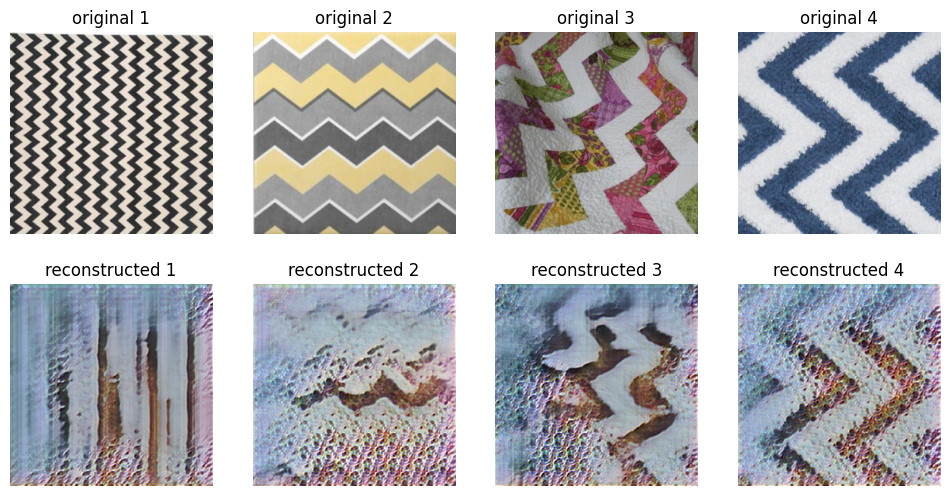

epoch 19


In [ ]:
epoch_save_path = os.path.join(save_path, f"epoch_19", "generator", "main_model.pth")
model = VQGAN().to(device)
model.load_state_dict(torch.load(epoch_save_path, weights_only=True))
visual_validation(model, val_loader, device)
print('epoch 19')